In [9]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from pathlib import Path
from collections import OrderedDict
config = {
    "font.family": 'serif',
    "font.size": 20,
    "mathtext.fontset": 'stix',
    "font.serif": ['SimSun'],
}
plt.rcParams.update(config)
plt.rcParams['axes.unicode_minus'] = False
def normalize_to_minimum(data_dict):
    """
    将所有算法的数据归一化到最小值
    即所有值除以全局最小值，这样最小值变为1，其他值表示相对于最小值的倍数
    """
    # 将所有数据展平成一个数组
    all_values = np.concatenate([values for values in data_dict.values()])
    
    # 计算全局最小值
    global_min = np.min(all_values)
    
    # 对每个算法的数据进行归一化（除以最小值）
    normalized_dict = OrderedDict()
    for algo, values in data_dict.items():
        normalized_values = values / global_min
        normalized_dict[algo] = normalized_values
    
    return normalized_dict

def plot_boxplot_from_directory(
    main_dir: str,
    metric: str = 'sim_round_time',
    figsize: tuple = (12, 8),
    dpi: int = 300,
    dataset_name: str = "Fashion-MNIST",
    dir_alpha: str = "0.1",
    total_rounds: int = 300
):
    """
    按照指定顺序从目录读取所有算法的数据，归一化后绘制彩色箱型图
    """
    # 定义算法的显示顺序
    algorithm_order = [
        'FedAGSA',
        'PyramidFL',
        'FedDocs',
        'TiFL',
        'FedAvg'
    ]
    
    # 获取颜色列表
    colors = plt.cm.tab10.colors
    
    # 获取所有算法目录并排序
    all_dirs = [d for d in os.listdir(main_dir) 
               if os.path.isdir(os.path.join(main_dir, d))]
    
    # 存储所有算法的原始数据
    data_dict = OrderedDict()
    
    # 首先按照预定义顺序处理算法
    for algo_name in algorithm_order:
        matching_dirs = [d for d in all_dirs if d.startswith(algo_name)]
        if matching_dirs:
            algo_dir = matching_dirs[0]
            result_file = os.path.join(main_dir, algo_dir, 'epoch_results_with_cumtime.csv')
            if os.path.exists(result_file):
                df = pd.read_csv(result_file)
                df = df.query(f"epoch <= {total_rounds}")
                if metric in df.columns:
                    data_dict[algo_name] = df[metric].values
    
    # 对数据进行归一化（相对于最小值）
    normalized_data = data_dict
    
    # 创建图形
    plt.figure(figsize=figsize)
    
    # 准备归一化后的数据用于绘图
    plot_data = []
    for algo, values in normalized_data.items():
        plot_data.extend([{'Algorithm': algo, 'Relative Training Time': val} for val in values])
    
    df_plot = pd.DataFrame(plot_data)
    
    # 使用seaborn绘制箱型图，为每个算法指定颜色
    # sns.boxplot(x="Algorithm", y="Relative Training Time", data=df_plot, 
    #             order=[algo for algo in algorithm_order if algo in normalized_data],
    #             showfliers=False,
    #             palette=colors[:len(normalized_data)])
    sns.boxplot(x="Algorithm", y="Relative Training Time", data=df_plot, 
                order=[algo for algo in algorithm_order if algo in normalized_data],
                showfliers=False,
                palette=colors[:len(normalized_data)])
        
    # 设置图形标题和标签
    # plt.title(f"System Efficiency Comparison on {dataset_name} (Dir={dir_alpha})")
    # plt.xlabel("Algorithms")
    # plt.ylabel("Relative Training Time per Round")
    plt.ylabel('时间开销（s）', fontsize=20)
    # 旋转x轴标签以防重叠
    plt.xticks()
    plt.xlabel('') 
    
    # 调整布局
    plt.tight_layout()
    
    # 保存图形
    output_path = os.path.join(main_dir, f"{dataset_name}_Dir{dir_alpha}_real_roundtime_boxplot.png")
    plt.savefig(output_path, dpi=dpi)
    plt.show()
    plt.close()
    
    return output_path


/tmp/ipykernel_460750/3237427628.py:96: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Algorithm", y="Relative Training Time", data=df_plot,


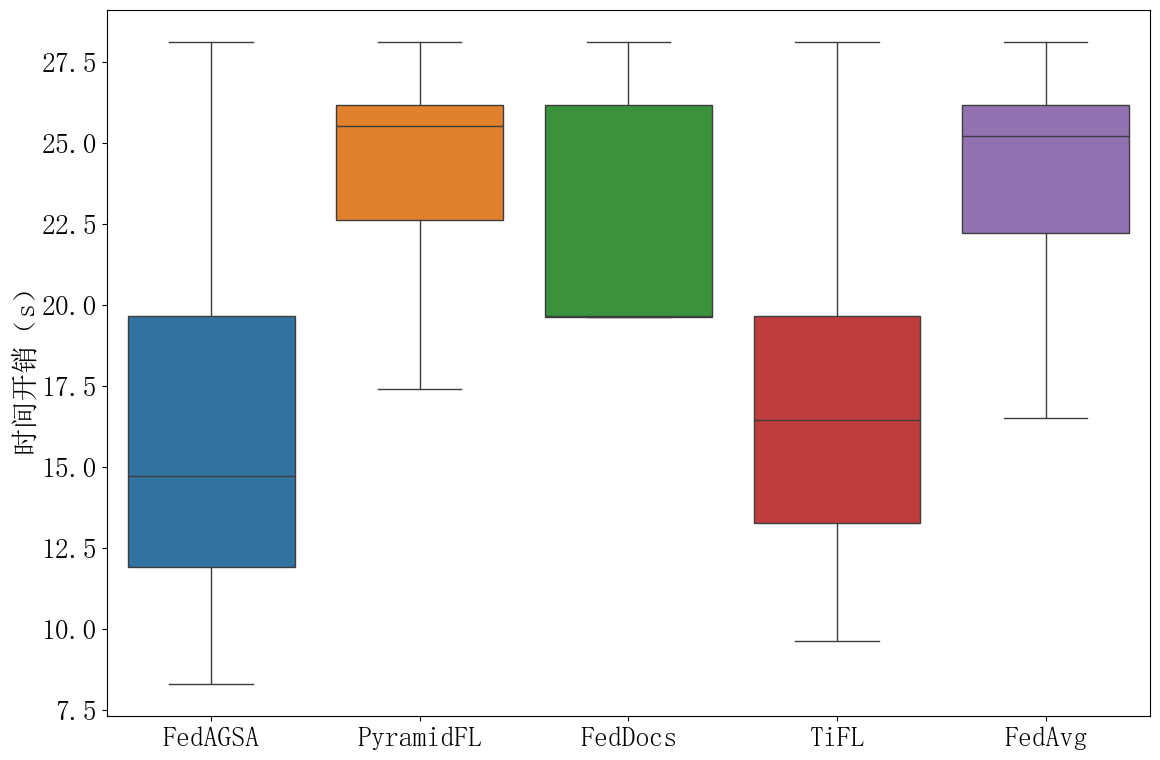

Boxplot saved to: ../PK/Exp2025-Cifar10-lr0.5-Dir0.1/CiFar-10_Dir0.1_real_roundtime_boxplot.png


In [10]:

# 使用示例
if __name__ == "__main__":
    # 指定目录路径
    directory = "../PK/Exp2025-Cifar10-lr0.5-Dir0.1"
    
    # 绘制箱型图
    output_file = plot_boxplot_from_directory(
        main_dir=directory,
        dataset_name="CiFar-10",
        dir_alpha="0.1",
        total_rounds=300
    )
    print(f"Boxplot saved to: {output_file}")

/tmp/ipykernel_460750/3237427628.py:96: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Algorithm", y="Relative Training Time", data=df_plot,


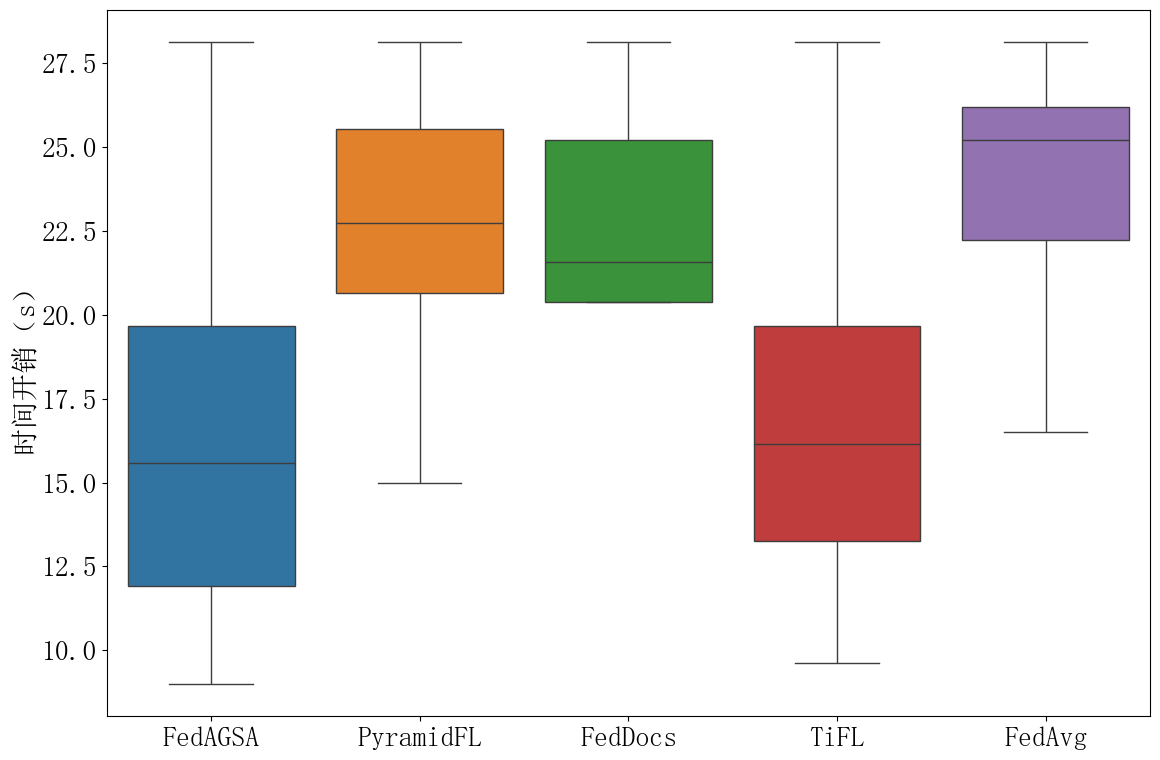

Boxplot saved to: ../PK/Exp2025-Cifar10-lr0.5-Dir0.5/CiFar-10_Dir0.5_real_roundtime_boxplot.png


In [11]:

# 使用示例
if __name__ == "__main__":
    # 指定目录路径
    directory = "../PK/Exp2025-Cifar10-lr0.5-Dir0.5"
    
    # 绘制箱型图
    output_file = plot_boxplot_from_directory(
        main_dir=directory,
        dataset_name="CiFar-10",
        dir_alpha="0.5",
        total_rounds=300
    )
    print(f"Boxplot saved to: {output_file}")